In [32]:
from pathlib import Path

import numpy as np
import pandas as pd
import os

# -----------------------------------------------------------------------------
# Data file
# -----------------------------------------------------------------------------
# The workbook name and location are fixed.
root_dir = os.path.abspath("../..")

CASE_ID = "C0003"

data_file = os.path.join(root_dir, "data", CASE_ID, 'C0003R02_PARK25_LC_1D_SCAN.xlsx')
sheet_name = 'Parameter scan'

data = pd.read_excel(data_file, sheet_name=sheet_name)

print(f'Data file: {data_file}')
print(f'Number of scan cases: {len(data)}')
data.head() # display the first five rows as a demo

Data file: d:\Workspace\eBATS\data\C0003\C0003R02_PARK25_LC_1D_SCAN.xlsx
Number of scan cases: 480


,m_dot_total_kg_s,T_water_in_C,Dh_mm,num_parallel_channels,u_water_m_s,Re_water,P_pump,E_pump_cumulative,m_plate_kg,m_coolant_kg,...,cruise_recovery_Tmax_C,Twater_out_cruise_end_C,dTmax_takeoff_C,dTmax_climb_C,dTmax_transition1_C,dTmax_cruise_C,dTmax_transition2_C,dTmax_descent_C,dTmax_hover_C,dTmax_landing_C
0,0.045,20,3,28,0.227773,681.005631,0.043278,83.094256,2.579877,0.081838,...,1.052304,20.462827,0.412637,1.417092,0.643737,-1.052304,-0.652175,0.526984,10.810119,0.280811
1,0.045,20,4,28,0.128122,510.754223,0.013694,26.291542,2.806896,0.145490,...,1.055711,20.462682,0.412596,1.416093,0.635834,-1.055711,-0.650525,0.527268,10.781822,0.279220
2,0.045,20,5,28,0.081998,408.603378,0.005609,10.769016,2.984378,0.227328,...,1.057705,20.462594,0.412571,1.415490,0.631051,-1.057705,-0.649529,0.527440,10.764693,0.278258
3,0.045,20,6,28,0.056943,340.502815,0.002705,5.193391,3.112323,0.327352,...,1.059014,20.462536,0.412554,1.415086,0.627845,-1.059014,-0.648862,0.527556,10.753211,0.277613
4,0.045,20,3,24,0.265735,794.506569,0.050491,96.943298,2.611723,0.070147,...,0.996352,20.464852,0.413169,1.429751,0.743456,-0.996352,-0.673327,0.523339,11.166119,0.300911


In [33]:
# Select the columns required for the thermal-performance analysis.
plot_data = data[
    [
        'm_dot_total_kg_s',
        'T_water_in_C',
        'Dh_mm',
        'num_parallel_channels',
        'Tmax_mission_C',
        'DeltaT_mission_max_C',
        'P_pump',
        'm_plate_kg',
        'm_coolant_kg',
        'mtotal',
    ]
].copy()

# Convert the plotting columns to numeric values.
for column in plot_data.columns:
    plot_data[column] = pd.to_numeric(plot_data[column], errors='raise')

plot_data.head()


,m_dot_total_kg_s,T_water_in_C,Dh_mm,num_parallel_channels,Tmax_mission_C,DeltaT_mission_max_C,P_pump,m_plate_kg,m_coolant_kg,mtotal
0,0.045,20,3,28,32.386900,2.202147,0.043278,2.579877,0.081838,2.661715
1,0.045,20,4,28,32.346597,2.228296,0.013694,2.806896,0.145490,2.952386
2,0.045,20,5,28,32.322269,2.244249,0.005609,2.984378,0.227328,3.211706
3,0.045,20,6,28,32.305988,2.254997,0.002705,3.112323,0.327352,3.439675
4,0.045,20,3,24,32.907066,1.894854,0.050491,2.611723,0.070147,2.681870


In [ ]:
def label_fmt(x):
    s = f"{x:.2f}"
    # if s.endswith("0"):
        # s = f"{x:0.0f}"
    # return rf"{s} \%" if plt.rcParams["text.usetex"] else f"{s} %"
    return s

24 rows for num_parallel_channels = 12
24 rows for num_parallel_channels = 16
24 rows for num_parallel_channels = 20
24 rows for num_parallel_channels = 24
24 rows for num_parallel_channels = 28


<Figure size 1600x300 with 0 Axes>

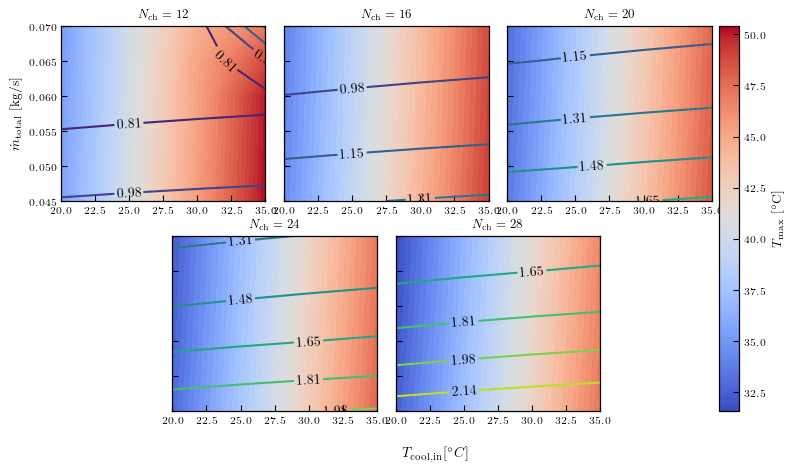

In [ ]:
# plot the maximum temperature at varying mass flow rate and inlet temperature for D_h = 4.0 mm

# plot a figure with five sub-figures
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize
from matplotlib import ticker
import numpy as np
from scipy.interpolate import griddata


# Apply the same scientific plotting style as the air-cooling figures.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': 8.5,
    'axes.labelsize': 9.5,
    'axes.titlesize': 9.0,
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})
# Create a mosaic where each plot is two entries wide.  Dots represent spaces.
mosaic = """AABBCC
            .DDEE."""

fig = plt.figure(figsize=(16, 3))
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("coolwarm", as_cmap=True), norm=plt.Normalize(vmin=T_min, vmax=T_max)))

D_h_selected = 4.0 

thermal_data = data[data['Dh_mm'] == D_h_selected]

thermal_data.head()

key_N_ch = "num_parallel_channels"
key_x = "T_water_in_C"
key_y = "m_dot_total_kg_s"
key_val_T = "Tmax_mission_C"
key_val_dT = "DeltaT_mission_max_C"

N_ch_array = np.sort(thermal_data[key_N_ch].unique())

# locate the maximum and minimum Tmax_mission_C to set the color ruler
T_max, T_min = thermal_data[key_val_T].max(), thermal_data[key_val_T].min()
dT_max, dT_min = thermal_data[key_val_dT].max(), thermal_data[key_val_dT].min()

# use one shared y-axis for all sub-figures
# plt.subplots_adjust(hspace=0.3, wspace=0.3)

fig, ax_dict = plt.subplot_mosaic(mosaic=mosaic, figsize=(10,5))

i = 0
for N_ch in N_ch_array:
    
    ax = ax_dict[chr(65+i)]  # A, B, C, D, E
    thermal_data_N_ch = thermal_data[thermal_data[key_N_ch] == N_ch]
    print(f"{len(thermal_data_N_ch)} rows for {key_N_ch} = {N_ch}")

    # select the subfigure for the current N_ch
    # ax = plt.subplot(1, 5, i + 1)
    
    
    # extract the values and transform them into a 2D array
     
    x_values = sorted(thermal_data_N_ch[key_x].unique())
    y_values = sorted(thermal_data_N_ch[key_y].unique())
    
    # fill in the Z values
    Z_values_T = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_T).values

    Z_values_dT = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_dT).values
    
    # calculate the space between contours
    contour_spacing = (T_max - T_min) / 10
    
    cmap = sns.color_palette("coolwarm", as_cmap=True)    
    cmap_dT = sns.color_palette("viridis", as_cmap=True)
    levels_dT = np.arange(dT_min, dT_max + (dT_max - dT_min) / 10, (dT_max - dT_min) / 10)
    
    ax.contourf(
        x_values, 
        y_values, 
        Z_values_T, 
        levels=50, 
        cmap=cmap, 
        vmin=T_min, 
        vmax=T_max)

    # display the contour values    
    cs = ax.contour(
        x_values, 
        y_values, 
        Z_values_dT, 
        levels=levels_dT,
        cmap=cmap_dT, 
        vmin=dT_min, 
        vmax=dT_max,
    )
    
    # ax.clabel(cs, cs.levels, fmt=label_fmt, fontsize=7)
    
    ax.clabel(cs, inline=True, fontsize=10, fmt=label_fmt, colors='black')
   
    # hide y-axis for subfigures 2-5
    if i != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
    
    
    # plot the channel number as the subfigure's title
    ax.set_title(rf"$N_\mathrm{{ch}}={N_ch}$")
    
    # if i == 4:        
    #     plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)), cax=ax)
    
    # if i == 4:
    #     cbar = plt.colorbar(
    #         plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)),
    #         ax=ax,            
    #     )
    i += 1
    
# use one shared x-axis label
# fig.supylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
fig.supxlabel(r"$T_\mathrm{cool,in} [^\circ C]$")

sm = plt.cm.ScalarMappable(
    cmap=sns.color_palette("coolwarm", as_cmap=True),
    norm=Normalize(vmin=T_min, vmax=T_max),
)
sm.set_array([])

fig.colorbar(sm, ax=fig.axes, label=r"$T_{\max}$ [$^\circ$C]", pad=0.01)



Tmax: 50.40356777874079 at mdot=0.045, Tin=35, N_ch=12
Tmin: 31.59042690993439 at mdot=0.07, Tin=20, N_ch=28
24 rows for num_parallel_channels = 12
24 rows for num_parallel_channels = 20
24 rows for num_parallel_channels = 28


<Figure size 1200x400 with 0 Axes>

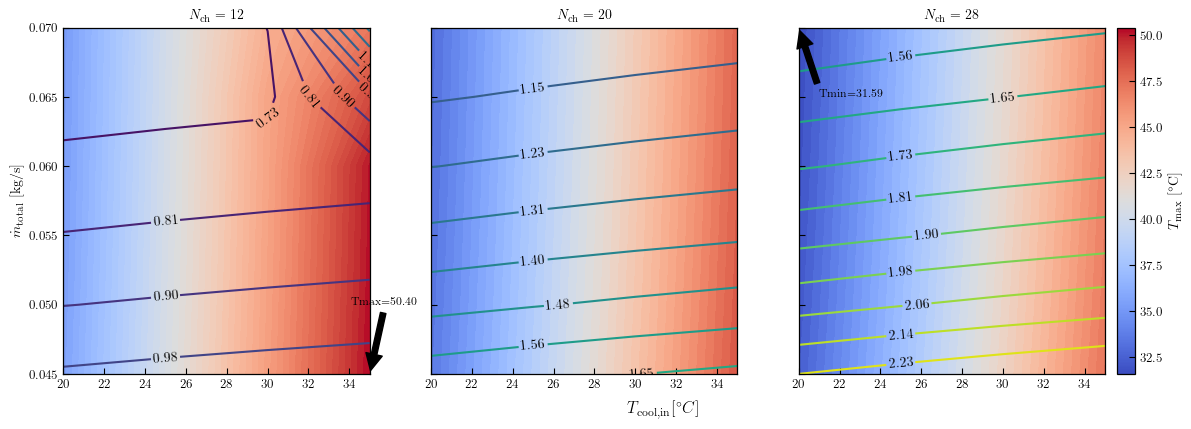

In [131]:
# plot the maximum temperature at varying mass flow rate and inlet temperature for D_h = 4.0 mm

# plot a figure with five sub-figures
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

base_fontsize = 10

# Apply the same scientific plotting style as the air-cooling figures.
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': base_fontsize,
    'axes.labelsize': base_fontsize,
    'axes.titlesize': base_fontsize,
    'xtick.labelsize': base_fontsize * 0.9,
    'ytick.labelsize': base_fontsize * 0.9,
    'axes.linewidth': 0.9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'axes.unicode_minus': False,
})

fig = plt.figure(figsize=(12, 4))
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=sns.color_palette("coolwarm", as_cmap=True), norm=plt.Normalize(vmin=T_min, vmax=T_max)))

D_h_selected = 4.0 

thermal_data = data[data['Dh_mm'] == D_h_selected]

thermal_data.head()

key_N_ch = "num_parallel_channels"
key_x = "T_water_in_C"
key_y = "m_dot_total_kg_s"
key_val_T = "Tmax_mission_C"
key_val_dT = "DeltaT_mission_max_C"

N_ch_array = [12, 20, 28]

# locate the maximum and minimum Tmax_mission_C to set the color ruler
T_max, T_min = thermal_data[key_val_T].max(), thermal_data[key_val_T].min()

# locate the row of the T_max and T_min
T_max_row = thermal_data[thermal_data[key_val_T] == T_max]
T_min_row = thermal_data[thermal_data[key_val_T] == T_min]

mdot_Tmax, Tin_Tmax, N_ch_Tmax = T_max_row[key_y].values[0], T_max_row[key_x].values[0], T_max_row[key_N_ch].values[0]
mdot_Tmin, Tin_Tmin, N_ch_Tmin = T_min_row[key_y].values[0], T_min_row[key_x].values[0], T_min_row[key_N_ch].values[0]

print(f"Tmax: {T_max} at mdot={mdot_Tmax}, Tin={Tin_Tmax}, N_ch={N_ch_Tmax}")
print(f"Tmin: {T_min} at mdot={mdot_Tmin}, Tin={Tin_Tmin}, N_ch={N_ch_Tmin}")

dT_max, dT_min = thermal_data[key_val_dT].max(), thermal_data[key_val_dT].min()

# use one shared y-axis for all sub-figures
# plt.subplots_adjust(hspace=0.3, wspace=0.3)

fig, ax_dict = plt.subplots(1, 3, figsize=(16, 4.5))  # Adjust the number of subplots as needed

i = 0
for N_ch in N_ch_array:
    
    ax = ax_dict[i]
    thermal_data_N_ch = thermal_data[thermal_data[key_N_ch] == N_ch]
    print(f"{len(thermal_data_N_ch)} rows for {key_N_ch} = {N_ch}")

    # select the subfigure for the current N_ch
    # ax = plt.subplot(1, 5, i + 1)
    
    
    # extract the values and transform them into a 2D array     
    x_values = sorted(thermal_data_N_ch[key_x].unique())
    y_values = sorted(thermal_data_N_ch[key_y].unique())
    
    # fill in the Z values
    Z_values_T = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_T).values

    Z_values_dT = thermal_data_N_ch.pivot(index=key_y, columns=key_x, values=key_val_dT).values
    
    # calculate the space between contours
    contour_spacing = (T_max - T_min) / 10
    
    cmap = sns.color_palette("coolwarm", as_cmap=True)    
    cmap_dT = sns.color_palette("viridis", as_cmap=True)
    space_num = 20
    levels_dT = np.arange(dT_min, dT_max + (dT_max - dT_min) / space_num, (dT_max - dT_min) / space_num)
    
    ax.contourf(
        x_values, 
        y_values, 
        Z_values_T, 
        levels=50, 
        cmap=cmap, 
        vmin=T_min, 
        vmax=T_max)

    # display the contour values    
    cs = ax.contour(
        x_values, 
        y_values, 
        Z_values_dT, 
        levels=levels_dT,
        cmap=cmap_dT, 
        vmin=dT_min, 
        vmax=dT_max,
    )
    
    # ax.clabel(cs, cs.levels, fmt=label_fmt, fontsize=7)
   
    if N_ch == 12:
        # annotate the global maximum
        ax.annotate(
            f"Tmax={T_max:.2f}",
            xy=(Tin_Tmax, mdot_Tmax),
            xytext=(Tin_Tmax - 0.9, mdot_Tmax + 0.005),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=8,
        )
    
    if N_ch == 28:
        # annotate the global minimum
        ax.annotate(
            f"Tmin={T_min:.2f}",
            xy=(Tin_Tmin, mdot_Tmin),
            xytext=(Tin_Tmin + 1, mdot_Tmin - 0.005),
            arrowprops=dict(facecolor='black', shrink=0.05),
            fontsize=8,
        )
     
    ax.clabel(cs, inline=True, fontsize=10, fmt=label_fmt, colors='black')
   
    # hide y-axis for subfigures 2-5
    if i != 0:
        ax.set_yticklabels([])
    else:
        ax.set_ylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
    
    
    # plot the channel number as the subfigure's title
    ax.set_title(rf"$N_\mathrm{{ch}}={N_ch}$")
    
    # if i == 4:        
    #     plt.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)), cax=ax)
    
    # if i == 4:
    #     cbar = plt.colorbar(
    #         plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=T_min, vmax=T_max)),
    #         ax=ax,            
    #     )
    i += 1
    
# use one shared x-axis label
# fig.supylabel(r"$\dot{m}_\mathrm{total}$ [kg/s]")
fig.supxlabel(r"$T_\mathrm{cool,in} [^\circ C]$")

sm = plt.cm.ScalarMappable(
    cmap=sns.color_palette("coolwarm", as_cmap=True),
    norm=Normalize(vmin=T_min, vmax=T_max),
)
sm.set_array([])

fig.colorbar(sm, ax=fig.axes, label=r"$T_{\max}$ [$^\circ$C]", pad=0.01)

# save the figure to a specified output folder (for paper drafting)

output_folder = r"D:\Workspace\Paper_eBATS\images" # the working directory of the paper draft

import os
if not os.path.exists(output_folder):
    os.makedirs(output_folder)
    
# overwrite the file
fig.savefig(os.path.join(output_folder, "Tmax_dT_LC_BTMS_scan.png"), dpi=300, bbox_inches='tight')
# plt.close()


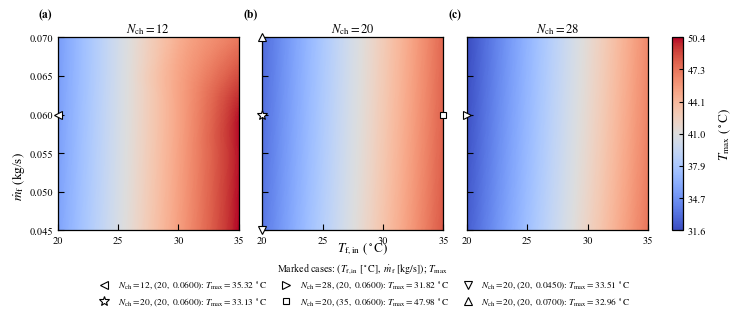

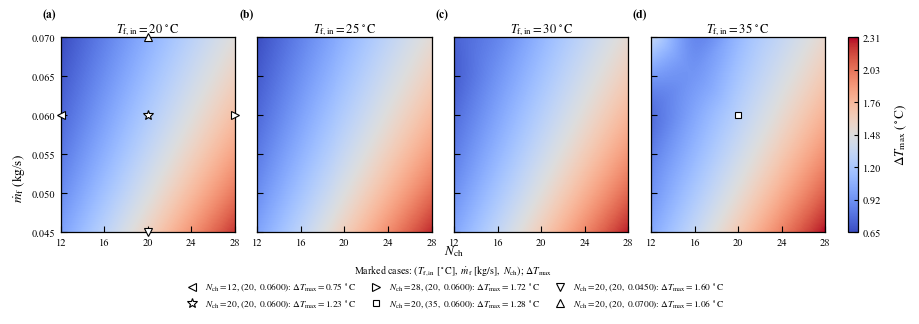

In [65]:
# -----------------------------------------------------------------------------
# Figures 2 and 3: complementary thermal-response maps at fixed Dh
# -----------------------------------------------------------------------------
fixed_dh_mm = 4.0

thermal_data = plot_data[
    np.isclose(plot_data['Dh_mm'], fixed_dh_mm)
].copy()

if thermal_data.empty:
    raise ValueError(
        f'No response-map cases were found for Dh = {fixed_dh_mm:g} mm.'
    )

mass_flow_values = np.sort(
    thermal_data['m_dot_total_kg_s'].dropna().unique().astype(float)
)
inlet_temperature_values = np.sort(
    thermal_data['T_water_in_C'].dropna().unique().astype(float)
)
all_channel_values = np.sort(
    thermal_data['num_parallel_channels'].dropna().unique().astype(float)
)

# Figure 2 uses three representative low-middle-high channel configurations.
selected_channel_values = np.array([12.0, 20.0, 28.0])
missing_channels = [
    value for value in selected_channel_values
    if not np.any(np.isclose(all_channel_values, value))
]
if missing_channels:
    raise ValueError(
        'Figure 2 requires N_ch = 12, 20, and 28, but the following levels '
        f'are missing: {missing_channels}'
    )

# Figure 3 uses the four scanned inlet-temperature levels.
if len(inlet_temperature_values) != 4:
    raise ValueError(
        'Figure 3 requires exactly four inlet-temperature levels, but '
        f'{len(inlet_temperature_values)} levels were found: '
        f'{inlet_temperature_values.tolist()}'
    )


# Cases used in the manuscript discussion.  The total mass-flow value written
# as 0.060 kg/s in the text is represented by the closest actual scan level.
discussion_mass_flow_kg_s = float(
    mass_flow_values[np.argmin(np.abs(mass_flow_values - 0.060))]
)

discussion_cases = [
    {
        'name': 'Low channel count',
        'T_f_in_C': float(inlet_temperature_values.min()),
        'm_dot_f_kg_s': discussion_mass_flow_kg_s,
        'N_ch': float(selected_channel_values.min()),
        'marker': '<',
        'size': 5.4,
        'facecolor': 'white',
    },
    {
        'name': 'Reference case',
        'T_f_in_C': float(inlet_temperature_values.min()),
        'm_dot_f_kg_s': discussion_mass_flow_kg_s,
        'N_ch': 20.0,
        'marker': '*',
        'size': 7.2,
        'facecolor': 'white',
    },
    {
        'name': 'High channel count',
        'T_f_in_C': float(inlet_temperature_values.min()),
        'm_dot_f_kg_s': discussion_mass_flow_kg_s,
        'N_ch': float(selected_channel_values.max()),
        'marker': '>',
        'size': 5.4,
        'facecolor': 'white',
    },
    {
        'name': 'High inlet temperature',
        'T_f_in_C': float(inlet_temperature_values.max()),
        'm_dot_f_kg_s': discussion_mass_flow_kg_s,
        'N_ch': 20.0,
        'marker': 's',
        'size': 4.8,
        'facecolor': 'white',
    },
    {
        'name': 'Low total mass flow',
        'T_f_in_C': float(inlet_temperature_values.min()),
        'm_dot_f_kg_s': float(mass_flow_values.min()),
        'N_ch': 20.0,
        'marker': 'v',
        'size': 5.2,
        'facecolor': 'white',
    },
    {
        'name': 'High total mass flow',
        'T_f_in_C': float(inlet_temperature_values.min()),
        'm_dot_f_kg_s': float(mass_flow_values.max()),
        'N_ch': 20.0,
        'marker': '^',
        'size': 5.2,
        'facecolor': 'white',
    },
]


def get_discussion_case_row(case):
    """Return the full-factorial scan row for one marked case."""
    case_mask = (
        np.isclose(thermal_data['T_water_in_C'], case['T_f_in_C'])
        & np.isclose(
            thermal_data['m_dot_total_kg_s'],
            case['m_dot_f_kg_s'],
            rtol=0.0,
            atol=1.0e-12,
        )
        & np.isclose(thermal_data['num_parallel_channels'], case['N_ch'])
    )
    case_rows = thermal_data.loc[case_mask]
    if case_rows.empty:
        raise ValueError(
            'A manuscript discussion case is missing from the scan table: '
            f"T_f,in={case['T_f_in_C']}, "
            f"m_dot_f={case['m_dot_f_kg_s']}, N_ch={case['N_ch']}."
        )
    return case_rows.iloc[0]


def plot_discussion_marker(axis, x_value, y_value, case):
    """Plot one manuscript discussion marker using the air-cooling style."""
    axis.plot(
        x_value,
        y_value,
        marker=case['marker'],
        markersize=case['size'],
        markerfacecolor=case['facecolor'],
        markeredgecolor='black',
        markeredgewidth=0.8,
        linestyle='none',
        clip_on=False,
        zorder=10,
    )


def build_marker_legend(metric_column, metric_symbol, value_decimals):
    """Build legend handles and labels for all marked manuscript cases."""
    handles = []
    labels = []
    for case in discussion_cases:
        case_row = get_discussion_case_row(case)
        metric_value = float(case_row[metric_column])
        handles.append(
            Line2D(
                [0],
                [0],
                marker=case['marker'],
                markersize=case['size'],
                markerfacecolor=case['facecolor'],
                markeredgecolor='black',
                markeredgewidth=0.8,
                linestyle='none',
            )
        )
        labels.append(
            rf"$N_{{\mathrm{{ch}}}}={case['N_ch']:g}$, "
            rf"$({case['T_f_in_C']:g},\ {case['m_dot_f_kg_s']:.4f})$: "
            + rf"${metric_symbol}={metric_value:.{value_decimals}f}\ ^\circ\mathrm{{C}}$"
        )
    return handles, labels


def coordinate_edges(coordinates):
    """Return pcolormesh cell edges for ordered discrete coordinates."""
    coordinates = np.asarray(coordinates, dtype=float)
    if coordinates.ndim != 1 or coordinates.size < 2:
        raise ValueError('At least two ordered coordinate levels are required.')

    midpoints = 0.5 * (coordinates[:-1] + coordinates[1:])
    first_edge = coordinates[0] - (midpoints[0] - coordinates[0])
    last_edge = coordinates[-1] + (coordinates[-1] - midpoints[-1])
    return np.concatenate(([first_edge], midpoints, [last_edge]))


def interpolate_response_field(panel_data, value_column, value_min, value_max):
    """Interpolate one response onto a dense inlet-temperature/flow grid."""
    inlet_temperature = panel_data['T_water_in_C'].to_numpy(dtype=float)
    mass_flow = panel_data['m_dot_total_kg_s'].to_numpy(dtype=float)
    values = panel_data[value_column].to_numpy(dtype=float)

    inlet_temperature_dense = np.linspace(
        inlet_temperature.min(), inlet_temperature.max(), 350
    )
    mass_flow_dense = np.linspace(mass_flow.min(), mass_flow.max(), 350)
    inlet_temperature_grid, mass_flow_grid = np.meshgrid(
        inlet_temperature_dense,
        mass_flow_dense,
    )

    value_grid = griddata(
        (inlet_temperature, mass_flow),
        values,
        (inlet_temperature_grid, mass_flow_grid),
        method='cubic',
    )

    # Fill edge NaNs with nearest-neighbour interpolation.
    if np.isnan(value_grid).any():
        nearest_grid = griddata(
            (inlet_temperature, mass_flow),
            values,
            (inlet_temperature_grid, mass_flow_grid),
            method='nearest',
        )
        value_grid = np.where(np.isnan(value_grid), nearest_grid, value_grid)

    # Prevent interpolation overshoots outside the original data range.
    value_grid = np.clip(value_grid, value_min, value_max)
    return inlet_temperature_grid, mass_flow_grid, value_grid


def interpolate_channel_flow_field(panel_data, value_column, value_min, value_max):
    """Interpolate one response onto a dense channel-number/flow grid."""
    channel_number = panel_data['num_parallel_channels'].to_numpy(dtype=float)
    mass_flow = panel_data['m_dot_total_kg_s'].to_numpy(dtype=float)
    values = panel_data[value_column].to_numpy(dtype=float)

    channel_number_dense = np.linspace(
        channel_number.min(), channel_number.max(), 350
    )
    mass_flow_dense = np.linspace(mass_flow.min(), mass_flow.max(), 350)
    channel_number_grid, mass_flow_grid = np.meshgrid(
        channel_number_dense,
        mass_flow_dense,
    )

    value_grid = griddata(
        (channel_number, mass_flow),
        values,
        (channel_number_grid, mass_flow_grid),
        method='cubic',
    )

    # Fill edge NaNs with nearest-neighbour interpolation.
    if np.isnan(value_grid).any():
        nearest_grid = griddata(
            (channel_number, mass_flow),
            values,
            (channel_number_grid, mass_flow_grid),
            method='nearest',
        )
        value_grid = np.where(np.isnan(value_grid), nearest_grid, value_grid)

    # Keep the smoothed field within the actual scan-data range.
    value_grid = np.clip(value_grid, value_min, value_max)
    return channel_number_grid, mass_flow_grid, value_grid


def response_matrix(panel_data, value_column):
    """Create a complete mass-flow-by-channel response matrix."""
    matrix = (
        panel_data.pivot(
            index='m_dot_total_kg_s',
            columns='num_parallel_channels',
            values=value_column,
        )
        .reindex(index=mass_flow_values, columns=all_channel_values)
        .to_numpy(dtype=float)
    )

    if np.isnan(matrix).any():
        raise ValueError(
            f'Missing combinations were found while constructing {value_column}. '
            'Check the full-factorial scan table.'
        )
    return matrix


def style_panel_axis(axis, panel_label, show_y_labels):
    """Apply the common scientific style to one heatmap panel."""
    axis.text(
        -0.105,
        1.085,
        panel_label,
        transform=axis.transAxes,
        horizontalalignment='left',
        verticalalignment='bottom',
        fontsize=8.5,
        fontweight='bold',
        color='black',
        clip_on=False,
        zorder=11,
    )

    if not show_y_labels:
        axis.tick_params(labelleft=False)

    for spine in axis.spines.values():
        spine.set_linewidth(0.9)
        spine.set_color('black')


# -----------------------------------------------------------------------------
# Figure 2: Tmax, divided into three subplots by Nch
# -----------------------------------------------------------------------------
figure2_data = thermal_data[
    thermal_data['num_parallel_channels'].isin(selected_channel_values)
].copy()

tmax_min = float(figure2_data['Tmax_mission_C'].min())
tmax_max = float(figure2_data['Tmax_mission_C'].max())
figure2_panel_labels = ['(a)', '(b)', '(c)']

fig2 = plt.figure(figsize=(7.35, 3.75))
fig2_grid = fig2.add_gridspec(
    nrows=1,
    ncols=4,
    width_ratios=[1, 1, 1, 0.060],
    left=0.085,
    right=0.935,
    bottom=0.355,
    top=0.870,
    wspace=0.17,
)

axes_tmax = [fig2.add_subplot(fig2_grid[0, col]) for col in range(3)]
colorbar_axis_tmax = fig2.add_subplot(fig2_grid[0, 3])
tmax_heatmap = None

for col, channel_number in enumerate(selected_channel_values):
    axis = axes_tmax[col]
    channel_data = figure2_data[
        np.isclose(
            figure2_data['num_parallel_channels'],
            channel_number,
        )
    ].copy()

    inlet_temperature_grid, mass_flow_grid, tmax_grid = (
        interpolate_response_field(
            channel_data,
            'Tmax_mission_C',
            tmax_min,
            tmax_max,
        )
    )

    tmax_heatmap = axis.pcolormesh(
        inlet_temperature_grid,
        mass_flow_grid,
        tmax_grid,
        cmap='coolwarm',
        shading='auto',
        vmin=tmax_min,
        vmax=tmax_max,
        rasterized=True,
    )

    # Mark all manuscript discussion cases belonging to this channel panel.
    for case in discussion_cases:
        if np.isclose(case['N_ch'], channel_number):
            plot_discussion_marker(
                axis,
                case['T_f_in_C'],
                case['m_dot_f_kg_s'],
                case,
            )

    axis.set_title(
        rf'$N_{{\mathrm{{ch}}}}={channel_number:g}$',
        pad=3.0,
    )
    axis.set_xlim(
        inlet_temperature_values.min(),
        inlet_temperature_values.max(),
    )
    axis.set_ylim(mass_flow_values.min(), mass_flow_values.max())
    axis.set_xticks(inlet_temperature_values)
    axis.set_yticks(mass_flow_values)
    axis.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    axis.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

    style_panel_axis(
        axis,
        figure2_panel_labels[col],
        show_y_labels=(col == 0),
    )

fig2.supxlabel(
    r'$T_{\mathrm{f,in}}$ ($^\circ$C)',
    y=0.285,
    fontsize=9.5,
)
fig2.supylabel(
    r'$\dot{m}_{\mathrm{f}}$ (kg/s)',
    x=0.020,
    fontsize=9.5,
)

tmax_colorbar_ticks = np.linspace(tmax_min, tmax_max, 7)
tmax_colorbar = fig2.colorbar(
    tmax_heatmap,
    cax=colorbar_axis_tmax,
    ticks=tmax_colorbar_ticks,
)
tmax_colorbar.set_label(
    r'$T_{\max}$ ($^\circ$C)',
    rotation=90,
    labelpad=8,
    fontsize=9.5,
)
tmax_colorbar.outline.set_linewidth(0.9)
tmax_colorbar.ax.tick_params(labelsize=7.5, width=0.8, length=3)
tmax_colorbar.ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter('%.1f')
)

# Shared marker legend for the Tmax response map.
figure2_legend_handles, figure2_legend_labels = build_marker_legend(
    'Tmax_mission_C',
    r'T_{\max}',
    2,
)
fig2.legend(
    figure2_legend_handles,
    figure2_legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.50, 0.125),
    ncol=3,
    frameon=False,
    title=(
        r'Marked cases: '
        r'$(T_{\mathrm{f,in}}\ [^\circ\mathrm{C}],\ '
        r'\dot{m}_{\mathrm{f}}\ [\mathrm{kg/s}])$; '
        r'$T_{\max}$'
    ),
    title_fontsize=7.2,
    fontsize=6.7,
    handletextpad=0.45,
    columnspacing=1.05,
    labelspacing=0.48,
)

plt.show()


# -----------------------------------------------------------------------------
# Figure 3: DeltaTmax, divided into four subplots by inlet temperature
# -----------------------------------------------------------------------------
# Use the same dense cubic interpolation strategy as Figure 2 so that the
# four panels are rendered as continuous heatmaps rather than discrete blocks.
delta_t_min = float(thermal_data['DeltaT_mission_max_C'].min())
delta_t_max = float(thermal_data['DeltaT_mission_max_C'].max())
figure3_panel_labels = ['(a)', '(b)', '(c)', '(d)']

fig3 = plt.figure(figsize=(9.20, 3.75))
fig3_grid = fig3.add_gridspec(
    nrows=1,
    ncols=5,
    width_ratios=[1, 1, 1, 1, 0.060],
    left=0.073,
    right=0.940,
    bottom=0.355,
    top=0.875,
    wspace=0.16,
)

axes_delta_t = [fig3.add_subplot(fig3_grid[0, col]) for col in range(4)]
colorbar_axis_delta_t = fig3.add_subplot(fig3_grid[0, 4])
delta_t_heatmap = None

for col, inlet_temperature_C in enumerate(inlet_temperature_values):
    axis = axes_delta_t[col]
    temperature_data = thermal_data[
        np.isclose(
            thermal_data['T_water_in_C'],
            inlet_temperature_C,
        )
    ].copy()

    channel_number_grid, mass_flow_grid, delta_t_grid = (
        interpolate_channel_flow_field(
            temperature_data,
            'DeltaT_mission_max_C',
            delta_t_min,
            delta_t_max,
        )
    )

    delta_t_heatmap = axis.pcolormesh(
        channel_number_grid,
        mass_flow_grid,
        delta_t_grid,
        cmap='coolwarm',
        shading='auto',
        vmin=delta_t_min,
        vmax=delta_t_max,
        rasterized=True,
    )

    # Mark all manuscript discussion cases belonging to this inlet-temperature panel.
    for case in discussion_cases:
        if np.isclose(case['T_f_in_C'], inlet_temperature_C):
            plot_discussion_marker(
                axis,
                case['N_ch'],
                case['m_dot_f_kg_s'],
                case,
            )

    axis.set_title(
        rf'$T_{{\mathrm{{f,in}}}}={inlet_temperature_C:g}\,^\circ\mathrm{{C}}$',
        pad=3.0,
    )
    axis.set_xlim(all_channel_values.min(), all_channel_values.max())
    axis.set_ylim(mass_flow_values.min(), mass_flow_values.max())
    axis.set_xticks(all_channel_values)
    axis.set_yticks(mass_flow_values)
    axis.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    axis.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

    style_panel_axis(
        axis,
        figure3_panel_labels[col],
        show_y_labels=(col == 0),
    )

fig3.supxlabel(
    r'$N_{\mathrm{ch}}$',
    y=0.285,
    fontsize=9.5,
)
fig3.supylabel(
    r'$\dot{m}_{\mathrm{f}}$ (kg/s)',
    x=0.018,
    fontsize=9.5,
)

delta_t_colorbar_ticks = np.linspace(delta_t_min, delta_t_max, 7)
delta_t_colorbar = fig3.colorbar(
    delta_t_heatmap,
    cax=colorbar_axis_delta_t,
    ticks=delta_t_colorbar_ticks,
)
delta_t_colorbar.set_label(
    r'$\Delta T_{\max}$ ($^\circ$C)',
    rotation=90,
    labelpad=8,
    fontsize=9.5,
)
delta_t_colorbar.outline.set_linewidth(0.9)
delta_t_colorbar.ax.tick_params(labelsize=7.5, width=0.8, length=3)
delta_t_colorbar.ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter('%.2f')
)

# Shared marker legend for the DeltaTmax response map.
figure3_legend_handles, figure3_legend_labels = build_marker_legend(
    'DeltaT_mission_max_C',
    r'\Delta T_{\max}',
    2,
)
fig3.legend(
    figure3_legend_handles,
    figure3_legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.50, 0.125),
    ncol=3,
    frameon=False,
    title=(
        r'Marked cases: '
        r'$(T_{\mathrm{f,in}}\ [^\circ\mathrm{C}],\ '
        r'\dot{m}_{\mathrm{f}}\ [\mathrm{kg/s}],\ N_{\mathrm{ch}})$; '
        r'$\Delta T_{\max}$'
    ),
    title_fontsize=7.2,
    fontsize=6.7,
    handletextpad=0.45,
    columnspacing=1.05,
    labelspacing=0.48,
)

plt.show()


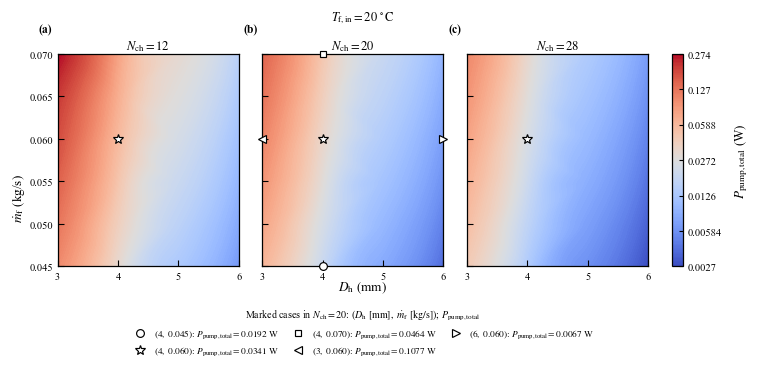

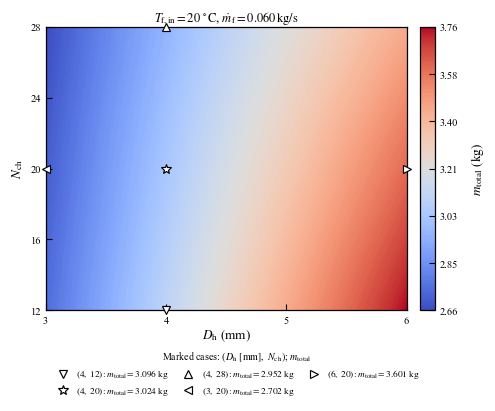

,Case,Nch,Dh (mm),Total mass flow (kg/s),Total pump power (W)
0,Low total mass flow,20.0,4.0,0.045,0.019171
1,Reference case,20.0,4.0,0.060,0.034082
2,High total mass flow,20.0,4.0,0.070,0.046389
3,Small hydraulic diameter,20.0,3.0,0.060,0.107715
4,Large hydraulic diameter,20.0,6.0,0.060,0.006732


,Nch,Dh (mm),Total mass flow (kg/s),Total pump power (W)
0,12.0,4.0,0.06,0.056803
1,20.0,4.0,0.06,0.034082
2,28.0,4.0,0.06,0.024344


,Case,Dh (mm),Nch,Cold-plate mass (kg),Coolant mass (kg),Total mass (kg)
0,Low channel count,4.0,12.0,3.033352,0.062353,3.095705
1,Reference case,4.0,20.0,2.920124,0.103921,3.024046
2,High channel count,4.0,28.0,2.806896,0.145490,2.952386
3,Small hydraulic diameter,3.0,20.0,2.643568,0.058456,2.702024
4,Large hydraulic diameter,6.0,20.0,3.367086,0.233823,3.600909


In [7]:
# -----------------------------------------------------------------------------
# Figures 4 and 5: pumping-power and mass characteristics
# -----------------------------------------------------------------------------
from matplotlib.colors import LogNorm

# Pumping power is independent of coolant inlet temperature in the present
# hydraulic model. One inlet-temperature slice is therefore sufficient.
power_inlet_temperature_C = 20.0
selected_power_channel_values = np.array([12.0, 20.0, 28.0])
power_reference_channel_number = 20.0
power_reference_dh_mm = 4.0

power_temperature_data = plot_data[
    np.isclose(plot_data['T_water_in_C'], power_inlet_temperature_C)
].copy()

available_power_channel_values = np.sort(
    power_temperature_data['num_parallel_channels']
    .dropna()
    .unique()
    .astype(float)
)
missing_power_channels = [
    value for value in selected_power_channel_values
    if not np.any(np.isclose(available_power_channel_values, value))
]
if missing_power_channels:
    raise ValueError(
        'The pumping-power comparison requires N_ch = 12, 20, and 28, '
        f'but the following levels are missing: {missing_power_channels}'
    )

power_data = power_temperature_data[
    power_temperature_data['num_parallel_channels'].isin(
        selected_power_channel_values
    )
].copy()

if power_data.empty:
    raise ValueError(
        'No pumping-power cases were found for '
        f'T_f,in={power_inlet_temperature_C:g} degC.'
    )

power_dh_values = np.sort(power_data['Dh_mm'].unique().astype(float))
power_flow_values = np.sort(
    power_data['m_dot_total_kg_s'].unique().astype(float)
)
power_reference_flow_kg_s = float(
    power_flow_values[np.argmin(np.abs(power_flow_values - 0.060))]
)


def interpolate_power_field(channel_data, value_min, value_max):
    """Interpolate one Nch pumping-power slice on a dense Dh-flow grid."""
    dh_dense = np.linspace(power_dh_values.min(), power_dh_values.max(), 420)
    flow_dense = np.linspace(
        power_flow_values.min(), power_flow_values.max(), 420
    )
    dh_grid, flow_grid = np.meshgrid(dh_dense, flow_dense)

    power_grid = griddata(
        (
            channel_data['Dh_mm'].to_numpy(dtype=float),
            channel_data['m_dot_total_kg_s'].to_numpy(dtype=float),
        ),
        channel_data['P_pump'].to_numpy(dtype=float),
        (dh_grid, flow_grid),
        method='cubic',
    )

    # Fill edge locations not covered by cubic interpolation with linear data.
    if np.isnan(power_grid).any():
        power_grid_linear = griddata(
            (
                channel_data['Dh_mm'].to_numpy(dtype=float),
                channel_data['m_dot_total_kg_s'].to_numpy(dtype=float),
            ),
            channel_data['P_pump'].to_numpy(dtype=float),
            (dh_grid, flow_grid),
            method='linear',
        )
        power_grid = np.where(
            np.isnan(power_grid), power_grid_linear, power_grid
        )

    return dh_grid, flow_grid, np.clip(power_grid, value_min, value_max)


power_min = float(power_data['P_pump'].min())
power_max = float(power_data['P_pump'].max())
if power_min <= 0.0:
    raise ValueError(
        'Logarithmic pumping-power scaling requires all P_pump values to be '
        f'positive, but the minimum value is {power_min}.'
    )
power_levels = np.geomspace(power_min, power_max, 160)
power_panel_labels = ['(a)', '(b)', '(c)']

# Figure 4 is the manuscript Figure 5: three Nch panels with one shared scale.
fig4 = plt.figure(figsize=(7.35, 4.05))
fig4_grid = fig4.add_gridspec(
    nrows=1,
    ncols=4,
    width_ratios=[1, 1, 1, 0.060],
    left=0.085,
    right=0.935,
    bottom=0.330,
    top=0.855,
    wspace=0.17,
)

axes_power = [fig4.add_subplot(fig4_grid[0, col]) for col in range(3)]
colorbar_axis_power = fig4.add_subplot(fig4_grid[0, 3])
power_heatmap = None

# Retain the original five discussion markers in the Nch = 20 panel.
power_discussion_cases = [
    {
        'name': 'Low total mass flow',
        'Dh_mm': power_reference_dh_mm,
        'm_dot_f_kg_s': float(power_flow_values.min()),
        'marker': 'o',
        'size': 5.6,
    },
    {
        'name': 'Reference case',
        'Dh_mm': power_reference_dh_mm,
        'm_dot_f_kg_s': power_reference_flow_kg_s,
        'marker': '*',
        'size': 7.4,
    },
    {
        'name': 'High total mass flow',
        'Dh_mm': power_reference_dh_mm,
        'm_dot_f_kg_s': float(power_flow_values.max()),
        'marker': 's',
        'size': 5.0,
    },
    {
        'name': 'Small hydraulic diameter',
        'Dh_mm': float(power_dh_values.min()),
        'm_dot_f_kg_s': power_reference_flow_kg_s,
        'marker': '<',
        'size': 5.4,
    },
    {
        'name': 'Large hydraulic diameter',
        'Dh_mm': float(power_dh_values.max()),
        'm_dot_f_kg_s': power_reference_flow_kg_s,
        'marker': '>',
        'size': 5.4,
    },
]

power_legend_handles = []
power_legend_labels = []
power_reference_rows = []

for col, channel_number in enumerate(selected_power_channel_values):
    axis = axes_power[col]
    channel_data = power_data[
        np.isclose(power_data['num_parallel_channels'], channel_number)
    ].copy()

    if channel_data.empty:
        raise ValueError(
            f'No pumping-power data were found for N_ch={channel_number:g}.'
        )

    dh_grid, flow_grid, channel_power_grid = interpolate_power_field(
        channel_data,
        power_min,
        power_max,
    )

    power_heatmap = axis.contourf(
        dh_grid,
        flow_grid,
        channel_power_grid,
        levels=power_levels,
        cmap='coolwarm',
        norm=LogNorm(vmin=power_min, vmax=power_max),
        antialiased=False,
    )

    # Mark the common reference operating point in every panel. Numerical
    # values are reported in the shared legend, so no in-panel annotation box
    # is added.
    reference_rows = channel_data[
        np.isclose(channel_data['Dh_mm'], power_reference_dh_mm)
        & np.isclose(
            channel_data['m_dot_total_kg_s'],
            power_reference_flow_kg_s,
            rtol=0.0,
            atol=1.0e-12,
        )
    ]
    if reference_rows.empty:
        raise ValueError(
            'Missing pumping-power reference case for '
            f'N_ch={channel_number:g}, Dh={power_reference_dh_mm:g} mm, '
            f'm_dot={power_reference_flow_kg_s:.3f} kg/s.'
        )

    reference_power = float(reference_rows.iloc[0]['P_pump'])
    power_reference_rows.append({
        'Nch': channel_number,
        'Dh (mm)': power_reference_dh_mm,
        'Total mass flow (kg/s)': power_reference_flow_kg_s,
        'Total pump power (W)': reference_power,
    })

    axis.plot(
        power_reference_dh_mm,
        power_reference_flow_kg_s,
        marker='*',
        markersize=7.4,
        markerfacecolor='white',
        markeredgecolor='black',
        markeredgewidth=0.85,
        linestyle='none',
        clip_on=False,
        zorder=10,
    )
    # Keep the low/high flow and small/large Dh markers in the central panel,
    # which is the slice used for the manuscript's hydraulic discussion.
    if np.isclose(channel_number, power_reference_channel_number):
        for case in power_discussion_cases:
            # The reference star has already been drawn above.
            if case['name'] != 'Reference case':
                axis.plot(
                    case['Dh_mm'],
                    case['m_dot_f_kg_s'],
                    marker=case['marker'],
                    markersize=case['size'],
                    markerfacecolor='white',
                    markeredgecolor='black',
                    markeredgewidth=0.85,
                    linestyle='none',
                    clip_on=False,
                    zorder=10,
                )

            case_rows = channel_data[
                np.isclose(channel_data['Dh_mm'], case['Dh_mm'])
                & np.isclose(
                    channel_data['m_dot_total_kg_s'],
                    case['m_dot_f_kg_s'],
                    rtol=0.0,
                    atol=1.0e-12,
                )
            ]
            if case_rows.empty:
                raise ValueError(
                    f"Missing pumping-power discussion case: {case['name']}"
                )

            power_value = float(case_rows.iloc[0]['P_pump'])
            power_legend_handles.append(
                Line2D(
                    [0],
                    [0],
                    marker=case['marker'],
                    markersize=case['size'],
                    markerfacecolor='white',
                    markeredgecolor='black',
                    markeredgewidth=0.85,
                    linestyle='none',
                )
            )
            power_legend_labels.append(
                rf'$({case["Dh_mm"]:g},\ {case["m_dot_f_kg_s"]:.3f})$: '
                rf'$P_{{\mathrm{{pump,total}}}}={power_value:.4f}$ W'
            )

    axis.set_title(
        rf'$N_{{\mathrm{{ch}}}}={channel_number:g}$',
        pad=3.0,
    )
    axis.set_xlim(power_dh_values.min(), power_dh_values.max())
    axis.set_ylim(power_flow_values.min(), power_flow_values.max())
    axis.set_xticks(power_dh_values)
    axis.set_yticks(power_flow_values)
    axis.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    axis.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

    style_panel_axis(
        axis,
        power_panel_labels[col],
        show_y_labels=(col == 0),
    )

fig4.supxlabel(
    r'$D_{\mathrm{h}}$ (mm)',
    y=0.260,
    fontsize=9.5,
)
fig4.supylabel(
    r'$\dot{m}_{\mathrm{f}}$ (kg/s)',
    x=0.020,
    fontsize=9.5,
)
fig4.suptitle(
    r'$T_{\mathrm{f,in}}=20\,^\circ\mathrm{C}$',
    y=0.965,
    fontsize=9.0,
)

power_colorbar_ticks = np.geomspace(power_min, power_max, 7)
power_colorbar = fig4.colorbar(
    power_heatmap,
    cax=colorbar_axis_power,
    ticks=power_colorbar_ticks,
)
power_colorbar.set_label(
    r'$P_{\mathrm{pump,total}}$ (W)',
    rotation=90,
    labelpad=8,
    fontsize=9.5,
)
power_colorbar.ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda value, position: f'{value:.3g}')
)
power_colorbar.outline.set_linewidth(0.9)
power_colorbar.ax.tick_params(labelsize=7.5, width=0.8, length=3)

# The shared legend refers to the five marked cases in the Nch = 20 panel.
fig4.legend(
    power_legend_handles,
    power_legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.50, 0.085),
    ncol=3,
    frameon=False,
    title=(
        r'Marked cases in $N_{\mathrm{ch}}=20$: '
        r'$(D_{\mathrm{h}}\ [\mathrm{mm}],\ '
        r'\dot{m}_{\mathrm{f}}\ [\mathrm{kg/s}])$; '
        r'$P_{\mathrm{pump,total}}$'
    ),
    title_fontsize=7.2,
    fontsize=6.7,
    handletextpad=0.45,
    columnspacing=1.05,
    labelspacing=0.48,
)

plt.show()




# Construct the total-mass map at the same reference inlet temperature and
# total coolant mass flow used in the hydraulic discussion.  Fixing these
# conditions also retains the small coolant-density effect included in the
# exported scan results.
mass_reference_flow_kg_s = float(
    power_flow_values[np.argmin(np.abs(power_flow_values - 0.060))]
)
mass_data = plot_data[
    np.isclose(plot_data['T_water_in_C'], power_inlet_temperature_C)
    & np.isclose(plot_data['m_dot_total_kg_s'], mass_reference_flow_kg_s)
][
    ['Dh_mm', 'num_parallel_channels', 'mtotal', 'm_plate_kg', 'm_coolant_kg']
].copy()

if mass_data.duplicated(subset=['Dh_mm', 'num_parallel_channels']).any():
    raise ValueError(
        'Duplicate mass cases were found at the selected reference conditions.'
    )

mass_dh_values = np.sort(mass_data['Dh_mm'].unique().astype(float))
mass_channel_values = np.sort(
    mass_data['num_parallel_channels'].unique().astype(float)
)

mass_dh_dense = np.linspace(mass_dh_values.min(), mass_dh_values.max(), 420)
mass_channel_dense = np.linspace(
    mass_channel_values.min(), mass_channel_values.max(), 420
)
mass_dh_grid, mass_channel_grid = np.meshgrid(
    mass_dh_dense,
    mass_channel_dense,
)

mass_grid = griddata(
    (
        mass_data['Dh_mm'].to_numpy(dtype=float),
        mass_data['num_parallel_channels'].to_numpy(dtype=float),
    ),
    mass_data['mtotal'].to_numpy(dtype=float),
    (mass_dh_grid, mass_channel_grid),
    method='cubic',
)
if np.isnan(mass_grid).any():
    mass_grid_linear = griddata(
        (
            mass_data['Dh_mm'].to_numpy(dtype=float),
            mass_data['num_parallel_channels'].to_numpy(dtype=float),
        ),
        mass_data['mtotal'].to_numpy(dtype=float),
        (mass_dh_grid, mass_channel_grid),
        method='linear',
    )
    mass_grid = np.where(np.isnan(mass_grid), mass_grid_linear, mass_grid)

mass_min = float(mass_data['mtotal'].min())
mass_max = float(mass_data['mtotal'].max())
mass_grid = np.clip(mass_grid, mass_min, mass_max)
mass_levels = np.linspace(mass_min, mass_max, 160)

fig5, axis_mass = plt.subplots(figsize=(5.10, 4.65))

mass_heatmap = axis_mass.contourf(
    mass_dh_grid,
    mass_channel_grid,
    mass_grid,
    levels=mass_levels,
    cmap='coolwarm',
    antialiased=False,
)

mass_discussion_cases = [
    {
        'name': 'Low channel count',
        'Dh_mm': 4.0,
        'N_ch': float(mass_channel_values.min()),
        'marker': 'v',
        'size': 5.4,
    },
    {
        'name': 'Reference case',
        'Dh_mm': 4.0,
        'N_ch': 20.0,
        'marker': '*',
        'size': 7.4,
    },
    {
        'name': 'High channel count',
        'Dh_mm': 4.0,
        'N_ch': float(mass_channel_values.max()),
        'marker': '^',
        'size': 5.4,
    },
    {
        'name': 'Small hydraulic diameter',
        'Dh_mm': float(mass_dh_values.min()),
        'N_ch': 20.0,
        'marker': '<',
        'size': 5.4,
    },
    {
        'name': 'Large hydraulic diameter',
        'Dh_mm': float(mass_dh_values.max()),
        'N_ch': 20.0,
        'marker': '>',
        'size': 5.4,
    },
]

mass_legend_handles = []
mass_legend_labels = []

for case in mass_discussion_cases:
    axis_mass.plot(
        case['Dh_mm'],
        case['N_ch'],
        marker=case['marker'],
        markersize=case['size'],
        markerfacecolor='white',
        markeredgecolor='black',
        markeredgewidth=0.85,
        linestyle='none',
        clip_on=False,
        zorder=10,
    )

    case_rows = mass_data[
        np.isclose(mass_data['Dh_mm'], case['Dh_mm'])
        & np.isclose(mass_data['num_parallel_channels'], case['N_ch'])
    ]
    if case_rows.empty:
        raise ValueError(f"Missing mass discussion case: {case['name']}")

    mass_value = float(case_rows.iloc[0]['mtotal'])
    mass_legend_handles.append(
        Line2D(
            [0],
            [0],
            marker=case['marker'],
            markersize=case['size'],
            markerfacecolor='white',
            markeredgecolor='black',
            markeredgewidth=0.85,
            linestyle='none',
        )
    )
    mass_legend_labels.append(
        rf'$({case["Dh_mm"]:g},\ {case["N_ch"]:g})$: '
        rf'$m_{{\mathrm{{total}}}}={mass_value:.3f}$ kg'
    )

axis_mass.set_xlim(mass_dh_values.min(), mass_dh_values.max())
axis_mass.set_ylim(mass_channel_values.min(), mass_channel_values.max())
axis_mass.set_xticks(mass_dh_values)
axis_mass.set_yticks(mass_channel_values)
axis_mass.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
axis_mass.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
axis_mass.set_xlabel(r'$D_{\mathrm{h}}$ (mm)', labelpad=1.0)
axis_mass.set_ylabel(r'$N_{\mathrm{ch}}$')
axis_mass.set_title(
    r'$T_{\mathrm{f,in}}=20\,^\circ\mathrm{C}$, '
    rf'$\dot{{m}}_{{\mathrm{{f}}}}={mass_reference_flow_kg_s:.3f}\,\mathrm{{kg/s}}$',
    pad=4.0,
)

mass_colorbar_ticks = np.linspace(mass_min, mass_max, 7)
mass_colorbar = fig5.colorbar(
    mass_heatmap,
    ax=axis_mass,
    ticks=mass_colorbar_ticks,
    pad=0.035,
    fraction=0.052,
)
mass_colorbar.set_label(r'$m_{\mathrm{total}}$ (kg)', labelpad=8)
mass_colorbar.ax.yaxis.set_major_formatter(
    ticker.FormatStrFormatter('%.2f')
)
mass_colorbar.outline.set_linewidth(0.9)

for spine in axis_mass.spines.values():
    spine.set_linewidth(0.9)
    spine.set_color('black')

fig5.subplots_adjust(bottom=0.270)
fig5.legend(
    mass_legend_handles,
    mass_legend_labels,
    loc='lower center',
    bbox_to_anchor=(0.50, 0.065),
    ncol=3,
    frameon=False,
    title=(
        r'Marked cases: '
        r'$(D_{\mathrm{h}}\ [\mathrm{mm}],\ N_{\mathrm{ch}})$; '
        r'$m_{\mathrm{total}}$'
    ),
    title_fontsize=7.2,
    fontsize=6.7,
    handletextpad=0.45,
    columnspacing=1.05,
    labelspacing=0.48,
)

plt.show()


# Display the exact values used in the pumping-power and mass discussions.
power_discussion_table = []
reference_channel_data = power_data[
    np.isclose(
        power_data['num_parallel_channels'],
        power_reference_channel_number,
    )
].copy()

for case in power_discussion_cases:
    row = reference_channel_data[
        np.isclose(reference_channel_data['Dh_mm'], case['Dh_mm'])
        & np.isclose(
            reference_channel_data['m_dot_total_kg_s'],
            case['m_dot_f_kg_s'],
            rtol=0.0,
            atol=1.0e-12,
        )
    ].iloc[0]
    power_discussion_table.append({
        'Case': case['name'],
        'Nch': power_reference_channel_number,
        'Dh (mm)': case['Dh_mm'],
        'Total mass flow (kg/s)': case['m_dot_f_kg_s'],
        'Total pump power (W)': float(row['P_pump']),
    })

display(pd.DataFrame(power_discussion_table).round(6))

# Direct comparison of Nch at the common reference Dh and total mass flow.
display(pd.DataFrame(power_reference_rows).round(6))

mass_discussion_table = []
for case in mass_discussion_cases:
    row = mass_data[
        np.isclose(mass_data['Dh_mm'], case['Dh_mm'])
        & np.isclose(mass_data['num_parallel_channels'], case['N_ch'])
    ].iloc[0]
    mass_discussion_table.append({
        'Case': case['name'],
        'Dh (mm)': case['Dh_mm'],
        'Nch': case['N_ch'],
        'Cold-plate mass (kg)': float(row['m_plate_kg']),
        'Coolant mass (kg)': float(row['m_coolant_kg']),
        'Total mass (kg)': float(row['mtotal']),
    })

display(pd.DataFrame(mass_discussion_table).round(6))


In [9]:
# -----------------------------------------------------------------------------
# Save the figures
# -----------------------------------------------------------------------------
program_name = 'C0003R02_PARK25_LC_1D_SCAN_plot'
output_dir = os.path.join(root_dir, "out", CASE_ID)
fig_root = f'{output_dir}/{program_name}'
os.makedirs(output_dir, exist_ok=True)

fig1_file = os.path.join(output_dir, f'{program_name}_Fig01_Dh_thermal_sensitivity.png')
fig2_file = os.path.join(output_dir, f'{program_name}_Fig02_Tmax_heatmaps_by_Nch_Dh4mm.png')
fig3_file = os.path.join(output_dir, f'{program_name}_Fig03_DeltaTmax_heatmaps_by_Tin_Dh4mm.png')
fig4_file = os.path.join(output_dir, f'{program_name}_Fig04_Ppump_total_heatmaps_by_Nch.png')
fig5_file = os.path.join(output_dir, f'{program_name}_Fig05_mtotal_heatmap.png')

save_settings = {
    'dpi': 900,
    'bbox_inches': 'tight',
    'facecolor': 'white',
}

fig1.savefig(fig1_file, **save_settings)
fig2.savefig(fig2_file, **save_settings)
fig3.savefig(fig3_file, **save_settings)
fig4.savefig(fig4_file, **save_settings)
fig5.savefig(fig5_file, **save_settings)

print(f'Figure 1 saved to: {fig1_file}')
print(f'Figure 2 saved to: {fig2_file}')
print(f'Figure 3 saved to: {fig3_file}')
print(f'Figure 4 saved to: {fig4_file}')
print(f'Figure 5 saved to: {fig5_file}')


Figure 1 saved to: d:\Workspace\eBATS\out\C0003\C0003R02_PARK25_LC_1D_SCAN_plot_Fig01_Dh_thermal_sensitivity.png
Figure 2 saved to: d:\Workspace\eBATS\out\C0003\C0003R02_PARK25_LC_1D_SCAN_plot_Fig02_Tmax_heatmaps_by_Nch_Dh4mm.png
Figure 3 saved to: d:\Workspace\eBATS\out\C0003\C0003R02_PARK25_LC_1D_SCAN_plot_Fig03_DeltaTmax_heatmaps_by_Tin_Dh4mm.png
Figure 4 saved to: d:\Workspace\eBATS\out\C0003\C0003R02_PARK25_LC_1D_SCAN_plot_Fig04_Ppump_total_heatmaps_by_Nch.png
Figure 5 saved to: d:\Workspace\eBATS\out\C0003\C0003R02_PARK25_LC_1D_SCAN_plot_Fig05_mtotal_heatmap.png
